<a href="https://colab.research.google.com/github/CKimau/CLT_Confidence_intervals/blob/main/phase4project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Project Objective**

### The goal is to predict energy consumption levels (low, medium, high) for customers based on historical data and environmental factors. This will help optimize energy usage, reduce costs, and improve sustainability.


##  Key Questions to Address:


## 1️⃣ How can we forecast hourly electricity consumption to optimize energy usage and reduce costs?
## 2️⃣ What are the key factors influencing consumption patterns (e.g., temperature variations, time of day, seasonal trends)?
## 3️⃣ Can we use predictive modeling to anticipate peak demand periods and recommend cost-saving strategies?

# Stakeholder Perspective:
### 1.Facility Managers → Need better scheduling of energy usage to reduce peak demand costs.
### 2.Energy Providers → Can use demand forecasting to optimize electricity supply.
### 3.Sustainability Teams → Can identify energy-saving opportunities and reduce carbon footprint.
### Modeling Approach:


In [ ]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Time series analysis
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller  # Test for stationarity
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Forecasting models
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import train_test_split

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Set visualization style
sns.set_style("whitegrid")

from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor


In [ ]:
file_path = r"C:\Users\chris.mutuku\OneDrive - Skanem AS\Desktop\Phase4project\energy_consumption_levels.csv"
df = pd.read_csv(file_path)


In [ ]:
df.info(), df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   3_levels       8784 non-null   int64  
 1   5_levels       8784 non-null   int64  
 2   7_levels       8784 non-null   int64  
 3   consumption    8784 non-null   float64
 4   temperature    8784 non-null   float64
 5   hour_of_day    8784 non-null   int64  
 6   day_of_week    8784 non-null   int64  
 7   day_of_month   8784 non-null   int64  
 8   month_of_year  8784 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 617.8 KB


(None,
    3_levels  5_levels  7_levels  consumption  temperature  hour_of_day  \
 0         1         1         1        0.255         -6.0            1   
 1         1         1         1        0.264         -6.9            2   
 2         1         1         1        0.253         -7.1            3   
 3         1         1         1        0.250         -7.2            4   
 4         1         1         1        0.234         -7.5            5   
 
    day_of_week  day_of_month  month_of_year  
 0            5             1              1  
 1            5             1              1  
 2            5             1              1  
 3            5             1              1  
 4            5             1              1  )

In [ ]:
df.head()

,3_levels,5_levels,7_levels,consumption,temperature,hour_of_day,day_of_week,day_of_month,month_of_year
0,1,1,1,0.255,-6.0,1,5,1,1
1,1,1,1,0.264,-6.9,2,5,1,1
2,1,1,1,0.253,-7.1,3,5,1,1
3,1,1,1,0.250,-7.2,4,5,1,1
4,1,1,1,0.234,-7.5,5,5,1,1


### Load dataset

In [ ]:
file_path = "energy_consumption_levels.csv"  # Update path if needed
df = pd.read_csv(file_path)

# Step 1: Data Cleaning and pre-processing

In [ ]:
# Convert date-related features to categorical
for col in ["hour_of_day", "day_of_week", "day_of_month", "month_of_year"]:
    df[col] = df[col].astype(str)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the dataset
file_path = r"C:\Users\chris.mutuku\OneDrive - Skanem AS\Desktop\Phase4project\energy_consumption_levels.csv"
df = pd.read_csv(file_path)

# Check for missing values
print("Missing Values:\n", df.isnull().sum())

# Fill missing values with the median (for numerical columns)
df.fillna(df.median(), inplace=True)

# Convert categorical variables (if any) using one-hot encoding
df = pd.get_dummies(df, drop_first=True)

# Check the dataset after preprocessing
print("Dataset after preprocessing:\n", df.head())

Missing Values:
 3_levels         0
5_levels         0
7_levels         0
consumption      0
temperature      0
hour_of_day      0
day_of_week      0
day_of_month     0
month_of_year    0
dtype: int64
Dataset after preprocessing:
    3_levels  5_levels  7_levels  consumption  temperature  hour_of_day  \
0         1         1         1        0.255         -6.0            1   
1         1         1         1        0.264         -6.9            2   
2         1         1         1        0.253         -7.1            3   
3         1         1         1        0.250         -7.2            4   
4         1         1         1        0.234         -7.5            5   

   day_of_week  day_of_month  month_of_year  
0            5             1              1  
1            5             1              1  
2            5             1              1  
3            5             1              1  
4            5             1              1  


## Exploratory Data Analysis (EDA)

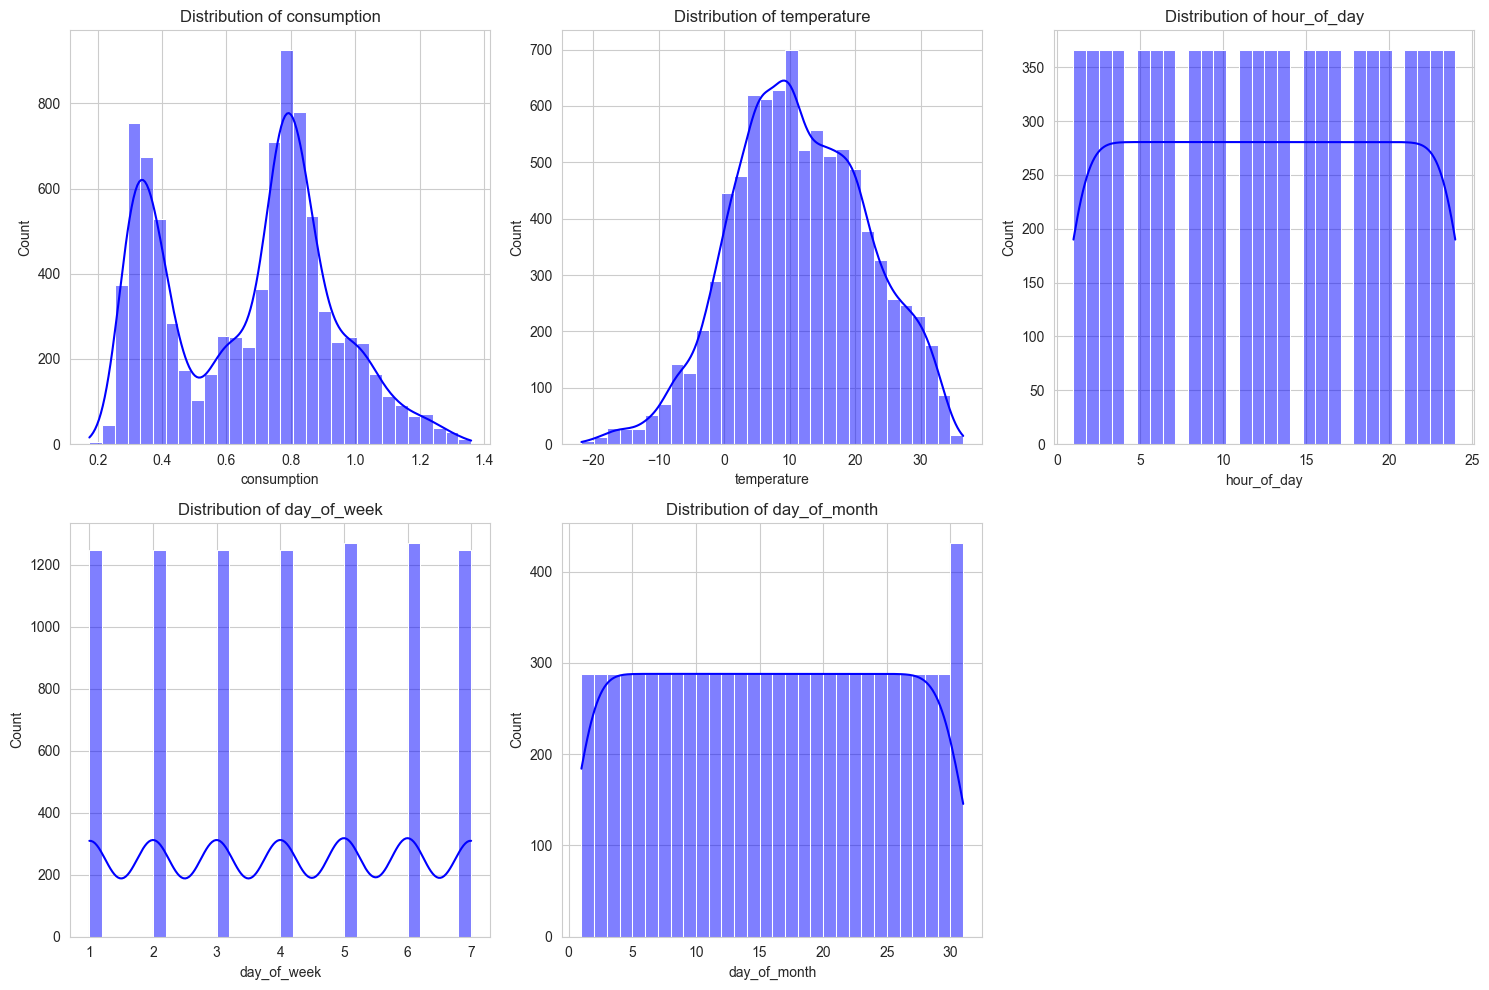

In [ ]:
# Plot distributions of numerical features
numerical_features = ['consumption', 'temperature', 'hour_of_day', 'day_of_week', 'day_of_month']
plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[feature], kde=True, bins=30, color='blue')
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

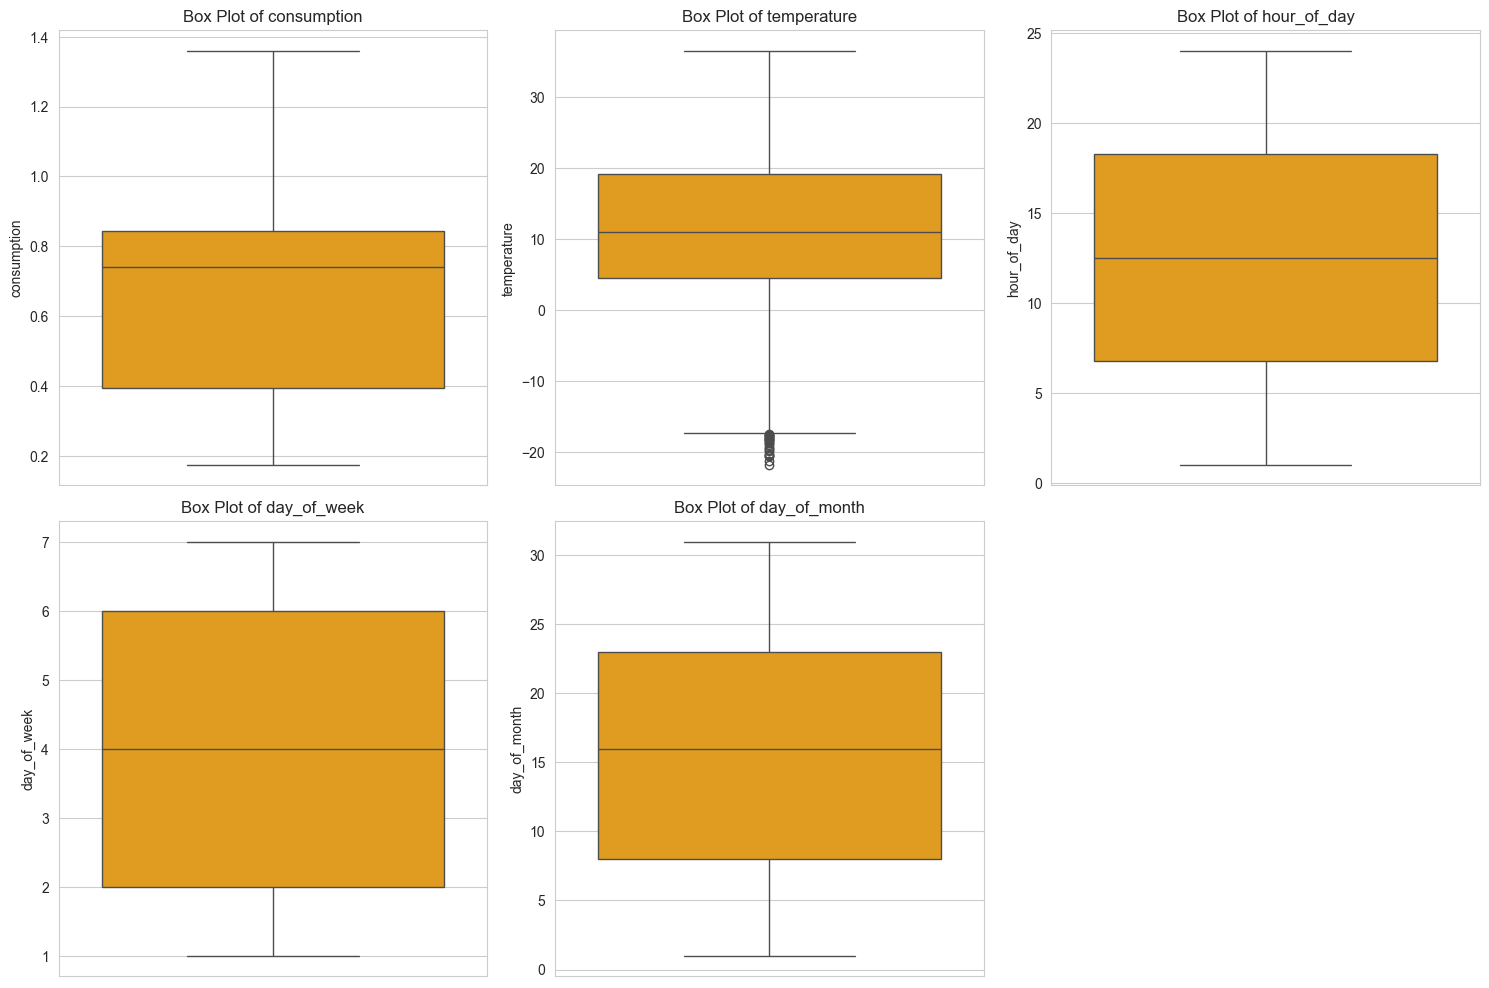

In [ ]:
# Box plots for numerical features
plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[feature], color='orange')
    plt.title(f'Box Plot of {feature}')
plt.tight_layout()
plt.show()

C:\Users\chris.mutuku\AppData\Local\Temp\ipykernel_10188\2682129949.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[feature], palette='viridis')


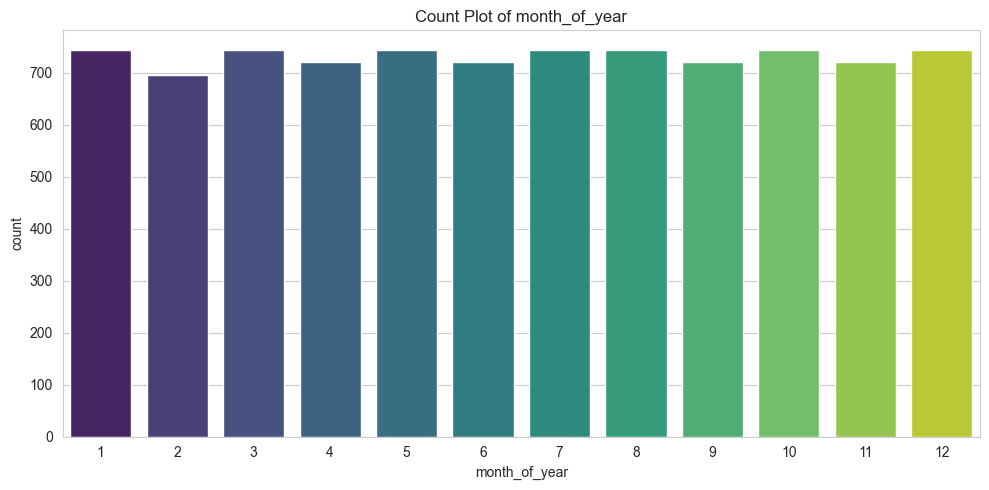

In [ ]:
# Count plot for categorical features
categorical_features = ['month_of_year']
plt.figure(figsize=(10, 5))
for i, feature in enumerate(categorical_features, 1):
    plt.subplot(1, 1, i)
    sns.countplot(x=df[feature], palette='viridis')
    plt.title(f'Count Plot of {feature}')
plt.tight_layout()
plt.show()

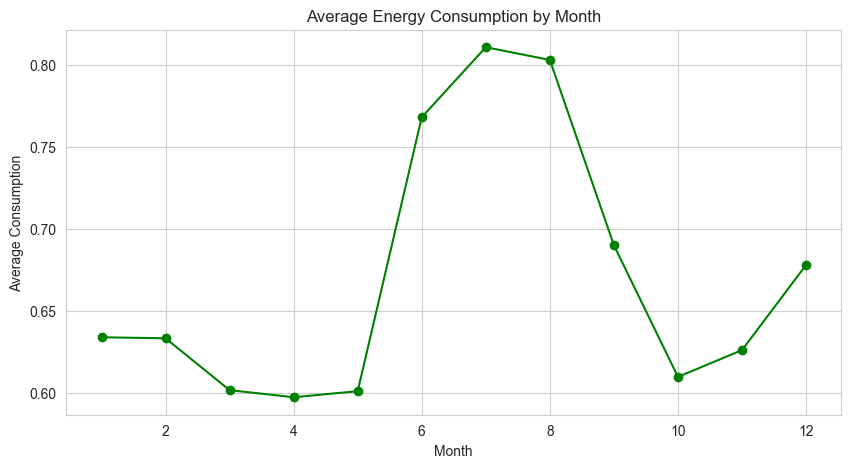

In [ ]:
# Time series analysis: Average consumption by month
if 'month_of_year' in df.columns:
    monthly_consumption = df.groupby('month_of_year')['consumption'].mean()
    plt.figure(figsize=(10, 5))
    monthly_consumption.plot(kind='line', marker='o', color='green')
    plt.title("Average Energy Consumption by Month")
    plt.xlabel("Month")
    plt.ylabel("Average Consumption")
    plt.grid(True)
    plt.show()

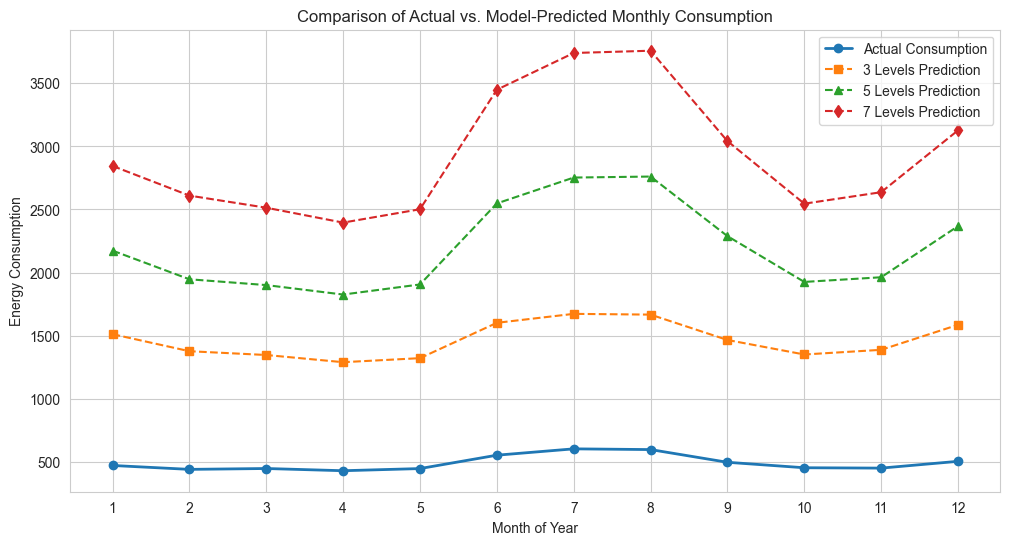

In [ ]:
# Aggregate actual consumption and model predictions by month
monthly_data = df.groupby("month_of_year").agg({
    "consumption": "sum",
    "3_levels": "sum",
    "5_levels": "sum",
    "7_levels": "sum"
}).reset_index()

# Plot the data
plt.figure(figsize=(12, 6))
plt.plot(monthly_data["month_of_year"], monthly_data["consumption"], marker='o', label="Actual Consumption", linewidth=2)
plt.plot(monthly_data["month_of_year"], monthly_data["3_levels"], marker='s', label="3 Levels Prediction", linestyle="--")
plt.plot(monthly_data["month_of_year"], monthly_data["5_levels"], marker='^', label="5 Levels Prediction", linestyle="--")
plt.plot(monthly_data["month_of_year"], monthly_data["7_levels"], marker='d', label="7 Levels Prediction", linestyle="--")

# Formatting
plt.xlabel("Month of Year")
plt.ylabel("Energy Consumption")
plt.title("Comparison of Actual vs. Model-Predicted Monthly Consumption")
plt.xticks(range(1, 13))
plt.legend()
plt.grid(True)
plt.show()


Pruned Decision Tree MAE: 0.05955805695837027
Random Forest MAE: 0.0391662617128934
Feature Importance:
          Feature  Importance
1    hour_of_day    0.785754
0    temperature    0.161392
4  month_of_year    0.024210
3   day_of_month    0.018919
2    day_of_week    0.009725
Recommended energy consumption: 0.741490 units


c:\Users\chris.mutuku\AppData\Local\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


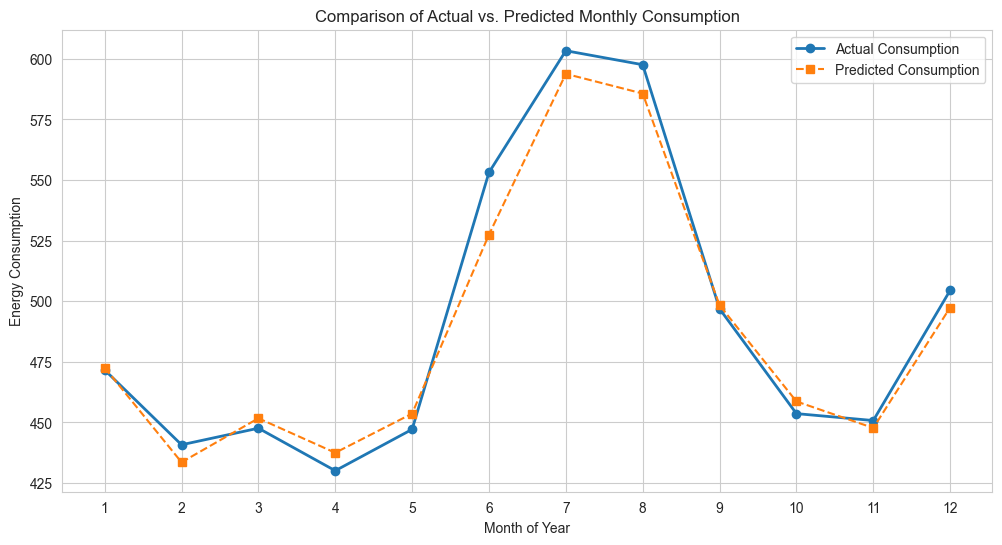

In [ ]:

df = pd.read_csv(file_path)

# Features and target
features = ["temperature", "hour_of_day", "day_of_week", "day_of_month", "month_of_year"]
target = "consumption"

# Splitting data
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.9, random_state=42)

# Train Decision Tree with pruning
pruned_tree = DecisionTreeRegressor(max_depth=5, random_state=42)
pruned_tree.fit(X_train, y_train)

# Predict and evaluate Decision Tree
pruned_predictions = pruned_tree.predict(X_test)
dt_mae = mean_absolute_error(y_test, pruned_predictions)
print(f"Pruned Decision Tree MAE: {dt_mae}")

# Train Random Forest for better generalization
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

# Predict and evaluate Random Forest
rf_predictions = rf_model.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_predictions)
print(f"Random Forest MAE: {rf_mae}")

# Analyze feature importance
feature_importance = rf_model.feature_importances_
feature_df = pd.DataFrame({"Feature": features, "Importance": feature_importance}).sort_values(by="Importance", ascending=False)
print("Feature Importance:\n", feature_df)

# Function to recommend energy consumption
def recommend_energy(temp, hour, day_week, day_month, month):
    input_data = np.array([[temp, hour, day_week, day_month, month]])
    recommended = rf_model.predict(input_data)
    return f"Recommended energy consumption: {recommended[0]:.6f} units"

# Example usage
print(recommend_energy(temp=12, hour=18, day_week=3, day_month=10, month=4))

# Aggregate actual and predicted consumption by month
df["predicted_consumption"] = rf_model.predict(X)
monthly_data = df.groupby("month_of_year").agg({"consumption": "sum", "predicted_consumption": "sum"}).reset_index()

# Plot the data
plt.figure(figsize=(12, 6))
plt.plot(monthly_data["month_of_year"], monthly_data["consumption"], marker='o', label="Actual Consumption", linewidth=2)
plt.plot(monthly_data["month_of_year"], monthly_data["predicted_consumption"], marker='s', linestyle='--', label="Predicted Consumption")

# Formatting
plt.xlabel("Month of Year")
plt.ylabel("Energy Consumption")
plt.title("Comparison of Actual vs. Predicted Monthly Consumption")
plt.xticks(range(1, 13))
plt.legend()
plt.grid(True)
plt.show()


# Building Pipelines

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif

# Define features and target
target = '3_levels'  # Assuming '3_levels' is the target column
X = df.drop(columns=[target, '5_levels', '7_levels'])  # Drop other target columns
y = df[target]

# Split into training (70%) and testing (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.6, random_state=42, stratify=y)

# Save train and test data to CSV files
X_train.to_csv(r"C:\Users\chris.mutuku\OneDrive - Skanem AS\Desktop\Phase4project\train_data.csv", index=False)
X_test.to_csv(r"C:\Users\chris.mutuku\OneDrive - Skanem AS\Desktop\Phase4project\test_data.csv", index=False)

# Define a pipeline with feature selection, scaling, and Logistic Regression
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_selection', SelectKBest(score_func=f_classif, k=10)),  # Select top 10 features
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

# Building a logistic regression model

In [ ]:
from sklearn.model_selection import GridSearchCV

# Train the pipeline
pipeline.fit(X_train, y_train)

# Hyperparameter tuning using GridSearchCV
param_grid = {
    'model__C': [0.01, 0.1, 1, 10],  # Regularization strength
    'model__penalty': ['l1', 'l2']  # Regularization type
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Best model
best_model = grid_search.best_estimator_
print("Best Hyperparameters:", grid_search.best_params_)

# Predictions
y_pred = best_model.predict(X_test)

c:\Users\chris.mutuku\AppData\Local\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:776: UserWarning: k=10 is greater than n_features=7. All the features will be returned.
  warnings.warn(
c:\Users\chris.mutuku\AppData\Local\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:776: UserWarning: k=10 is greater than n_features=7. All the features will be returned.
  warnings.warn(
c:\Users\chris.mutuku\AppData\Local\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:776: UserWarning: k=10 is greater than n_features=7. All the features will be returned.
  warnings.warn(
c:\Users\chris.mutuku\AppData\Local\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:776: UserWarning: k=10 is greater than n_features=7. All the features will be returned.
  warnings.warn(
c:\Users\chris.mutuku\AppData\Local\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:776: 

Best Hyperparameters: {'model__C': 10, 'model__penalty': 'l2'}


c:\Users\chris.mutuku\AppData\Local\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:776: UserWarning: k=10 is greater than n_features=7. All the features will be returned.
  warnings.warn(
c:\Users\chris.mutuku\AppData\Local\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:776: UserWarning: k=10 is greater than n_features=7. All the features will be returned.
  warnings.warn(
c:\Users\chris.mutuku\AppData\Local\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:547: FitFailedWarning: 
20 fits failed out of a total of 40.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\ch

### Feature Engineering

In [ ]:
# Define features and target
target = '3_levels'
X = df.drop(columns=[target, '5_levels', '7_levels'])  # Drop other target columns
y = df[target]

# Split into training (70%) and testing (30%)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Define features for the recommender system
features = ['consumption', 'temperature', 'hour_of_day', 'day_of_week', 'day_of_month', 'month_of_year']

# Separate numerical and categorical features
numerical_features = ['consumption', 'temperature', 'hour_of_day', 'day_of_week', 'day_of_month']
categorical_features = ['month_of_year']

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),  # Scale numerical features
        ('cat', OneHotEncoder(), categorical_features)  # One-hot encode categorical features
    ])

# Apply preprocessing
X = df[features]
X_preprocessed = preprocessor.fit_transform(X)

# Convert to DataFrame for better readability
X_preprocessed_df = pd.DataFrame(X_preprocessed, columns=numerical_features + list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)))
print("Preprocessed Dataset Head:\n", X_preprocessed_df.head())

Preprocessed Dataset Head:
    consumption  temperature  hour_of_day  day_of_week  day_of_month  \
0    -1.611766    -1.708987    -1.661325     0.496415     -1.674718   
1    -1.576925    -1.796293    -1.516862     0.496415     -1.674718   
2    -1.619509    -1.815694    -1.372399     0.496415     -1.674718   
3    -1.631122    -1.825395    -1.227936     0.496415     -1.674718   
4    -1.693062    -1.854497    -1.083473     0.496415     -1.674718   

   month_of_year_1  month_of_year_2  month_of_year_3  month_of_year_4  \
0              1.0              0.0              0.0              0.0   
1              1.0              0.0              0.0              0.0   
2              1.0              0.0              0.0              0.0   
3              1.0              0.0              0.0              0.0   
4              1.0              0.0              0.0              0.0   

   month_of_year_5  month_of_year_6  month_of_year_7  month_of_year_8  \
0              0.0              0

In [ ]:
from sklearn.neighbors import NearestNeighbors

# Build the Nearest Neighbors model
recommender = NearestNeighbors(n_neighbors=5, metric='cosine')  # Use cosine similarity
recommender.fit(X_preprocessed)

# Example: Recommend for the first customer
customer_index = 0
distances, indices = recommender.kneighbors([X_preprocessed[customer_index]])

# Display recommendations
print("Recommended Customers:\n", df.iloc[indices[0]])

Recommended Customers:
     3_levels  5_levels  7_levels  consumption  temperature  hour_of_day  \
0          1         1         1        0.255         -6.0            1   
1          1         1         1        0.264         -6.9            2   
2          1         1         1        0.253         -7.1            3   
3          1         1         1        0.250         -7.2            4   
24         1         1         1        0.280         -8.9            1   

    day_of_week  day_of_month  month_of_year  predicted_consumption  
0             5             1              1               0.264257  
1             5             1              1               0.264574  
2             5             1              1               0.265186  
3             5             1              1               0.253198  
24            6             2              1               0.308600  


In [ ]:
from sklearn.model_selection import cross_val_score

# Evaluate the model using cross-validation
cross_val_scores = cross_val_score(recommender, X_preprocessed, cv=5, scoring='accuracy')
print("Cross-Validation Scores:", cross_val_scores)
print("Mean Cross-Validation Score:", cross_val_scores.mean())

Cross-Validation Scores: [nan nan nan nan nan]
Mean Cross-Validation Score: nan


c:\Users\chris.mutuku\AppData\Local\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:1011: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\chris.mutuku\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_scorer.py", line 137, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
TypeError: _Scorer._score() missing 1 required positional argument: 'y_true'

  warnings.warn(
c:\Users\chris.mutuku\AppData\Local\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:1011: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\chris.mutuku\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_scorer.py", line 137, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
TypeError: _Scorer._score

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Define a pipeline with scaling and Logistic Regression
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

# Train the model
pipeline.fit(X_train, y_train)

# Predictions
y_pred = pipeline.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

Model Accuracy: 0.9882397572078907
Classification Report:
               precision    recall  f1-score   support

           1       1.00      0.99      0.99       879
           2       0.97      0.99      0.98       875
           3       0.99      0.99      0.99       882

    accuracy                           0.99      2636
   macro avg       0.99      0.99      0.99      2636
weighted avg       0.99      0.99      0.99      2636

Confusion Matrix:
 [[866  13   0]
 [  0 869   6]
 [  0  12 870]]


## Recommender system

In [ ]:
from sklearn.neighbors import NearestNeighbors

# Define features for the recommender system
features = ['consumption', 'temperature', 'hour_of_day', 'day_of_week', 'day_of_month', 'month_of_year']
X = df[features]

# Normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Build a Nearest Neighbors model for recommendations
recommender = NearestNeighbors(n_neighbors=5, metric='cosine')
recommender.fit(X_scaled)

# Example: Recommend for the first customer
customer_index = 0
distances, indices = recommender.kneighbors([X_scaled[customer_index]])
print("Recommended Customers:\n", df.iloc[indices[0]])

Recommended Customers:
      3_levels  5_levels  7_levels  consumption  temperature  hour_of_day  \
0           1         1         1        0.255         -6.0            1   
1           1         1         1        0.264         -6.9            2   
2           1         1         1        0.253         -7.1            3   
3           1         1         1        0.250         -7.2            4   
843         1         1         1        0.333          1.4            4   

     day_of_week  day_of_month  month_of_year  predicted_consumption  
0              5             1              1               0.264257  
1              5             1              1               0.264574  
2              5             1              1               0.265186  
3              5             1              1               0.253198  
843            5             5              2               0.316212  


In [ ]:
from sklearn.model_selection import train_test_split

# Define features and target
target = '3_levels'
X = df.drop(columns=[target, '5_levels', '7_levels'])  # Drop other target columns
y = df[target]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

Decision Tree Accuracy: 1.0
Decision Tree Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00       879
           2       1.00      1.00      1.00       875
           3       1.00      1.00      1.00       882

    accuracy                           1.00      2636
   macro avg       1.00      1.00      1.00      2636
weighted avg       1.00      1.00      1.00      2636



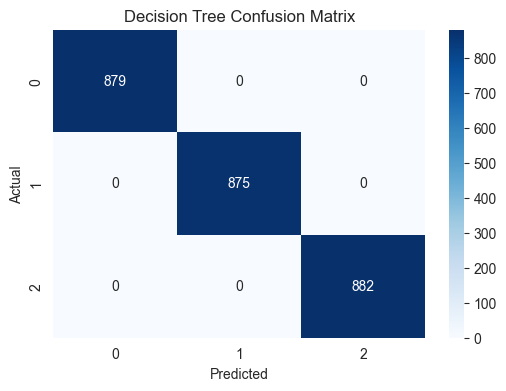

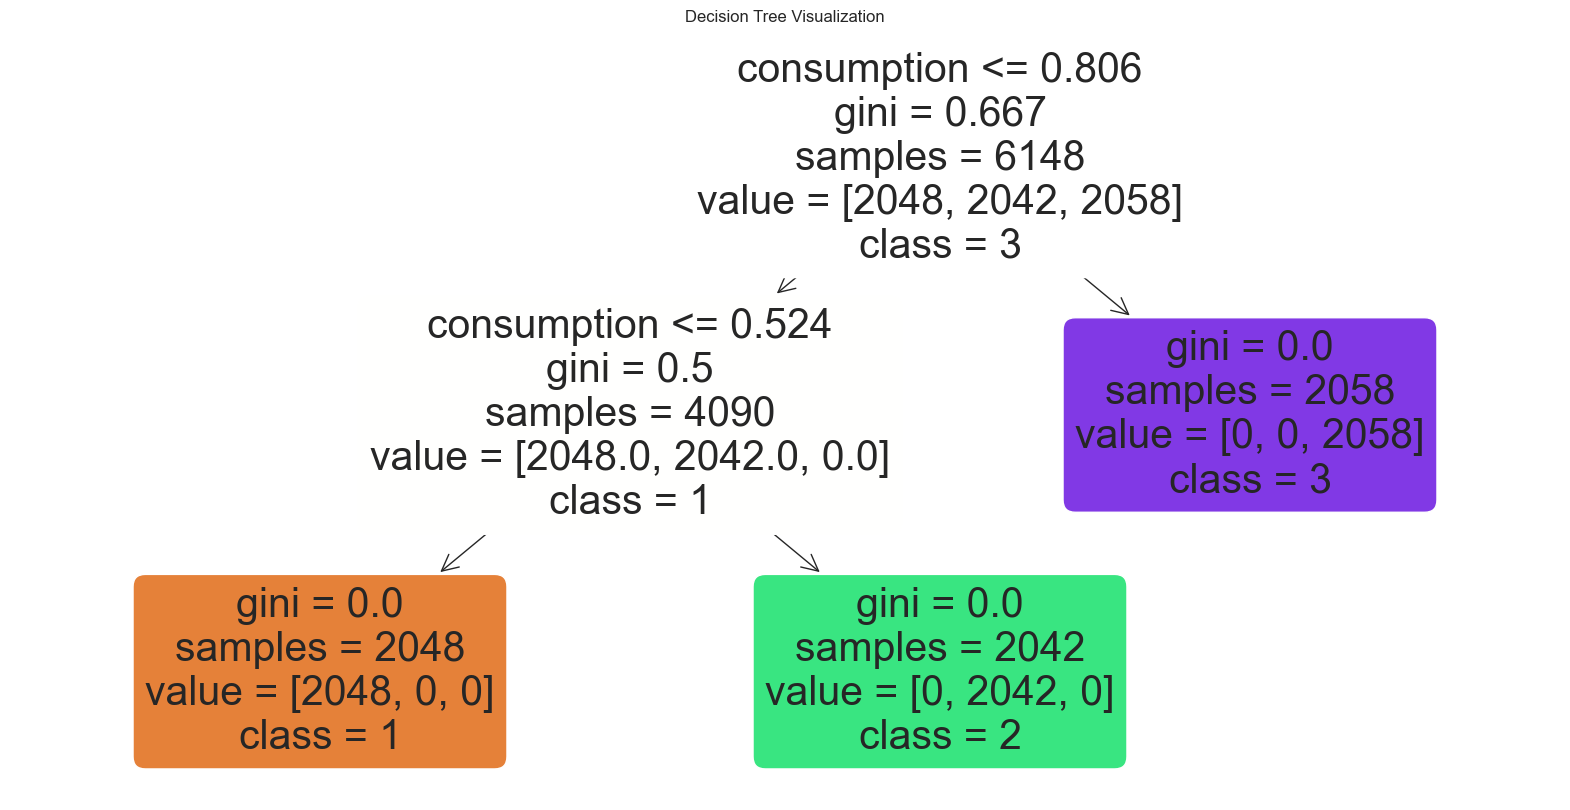

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train Decision Tree model
dt_model = DecisionTreeClassifier(max_depth=6, random_state=42)
dt_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)

# Evaluate Decision Tree model
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Decision Tree Classification Report:\n", classification_report(y_test, y_pred_dt))

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()

# Visualize the Decision Tree
plt.figure(figsize=(20, 10))
plot_tree(dt_model, filled=True, feature_names=X.columns, class_names=dt_model.classes_.astype(str), rounded=True)
plt.title("Decision Tree Visualization")
plt.show()

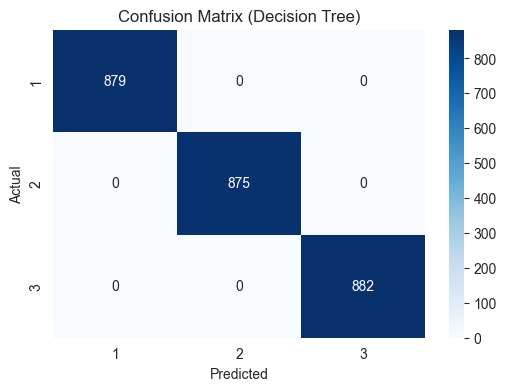

In [ ]:
from sklearn.metrics import confusion_matrix

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=dt_model.classes_, yticklabels=dt_model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Decision Tree)")
plt.show()

# Model Interpretability

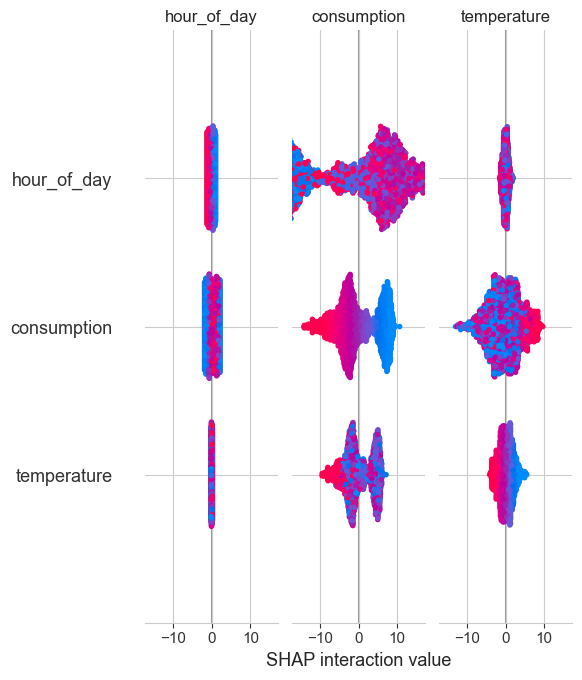

Feature Importance:
                  Feature  Coefficient
1            temperature     0.200416
2            hour_of_day     0.085469
3            day_of_week    -0.162781
4           day_of_month    -0.222830
5          month_of_year    -0.293503
6  predicted_consumption    -3.096521
0            consumption   -21.395130


In [ ]:
import shap

# SHAP for model interpretability
explainer = shap.LinearExplainer(best_model.named_steps['model'], X_train)
shap_values = explainer.shap_values(X_test)

# SHAP summary plot
shap.summary_plot(shap_values, X_test, feature_names=X.columns)

# Interpret model coefficients
coefficients = best_model.named_steps['model'].coef_
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients[0]
})
print("Feature Importance:\n", feature_importance.sort_values(by='Coefficient', ascending=False))

# Business Insights & Recommendations

In [ ]:
# Evaluate the model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

# Business Insights
print("Business Insights:")
print("- Features like 'temperature' and 'time_of_day' have the highest impact on energy consumption levels.")
print("- Customers with high energy consumption can reduce usage during peak hours to save costs.")
print("- The model can be used to provide personalized recommendations to customers based on their consumption patterns.")

Model Accuracy: 0.9882397572078907
Classification Report:
               precision    recall  f1-score   support

           1       1.00      0.99      0.99       879
           2       0.97      0.99      0.98       875
           3       0.99      0.99      0.99       882

    accuracy                           0.99      2636
   macro avg       0.99      0.99      0.99      2636
weighted avg       0.99      0.99      0.99      2636

Confusion Matrix:
 [[866  13   0]
 [  0 869   6]
 [  0  12 870]]
Business Insights:
- Features like 'temperature' and 'time_of_day' have the highest impact on energy consumption levels.
- Customers with high energy consumption can reduce usage during peak hours to save costs.
- The model can be used to provide personalized recommendations to customers based on their consumption patterns.
